In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import tqdm
import random
import string

# GPU Libraries
import cudf
import cupy as cp

In [5]:
# For final DataFrame conversion and display


# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return "".join(random.choices(string.ascii_letters, k=length))


# Function to generate a cuDF DataFrame with a dedicated 'unique_col'
# whose distinct values are controlled by the 'cardinality' parameter.
# Also adds additional columns with mixed data types.
def generate_unique_df(n_rows, num_cols, cardinality, unique_dtype="int"):
    data = {}

    # Generate the 'unique_col' with controlled cardinality.
    if unique_dtype == "int":
        # For integers, generate values between 0 and (cardinality - 1)
        data["unique_col"] = np.random.randint(0, cardinality, n_rows)
    elif unique_dtype == "float":
        # For floats, generate similar integer values and cast to float.
        data["unique_col"] = np.random.randint(0, cardinality, n_rows).astype(float)
    elif unique_dtype == "string":
        # For strings, generate a fixed pool of random strings and sample from it.
        unique_values = [random_string(5) for _ in range(cardinality)]
        data["unique_col"] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")

    # Add additional columns with mixed data types.
    for i in range(num_cols - 1):  # subtract one for the 'unique_col'
        col_type = random.choice(["int", "float", "string"])
        col_name = f"col_{i}"
        if col_type == "int":
            data[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == "float":
            data[col_name] = np.random.rand(n_rows)
        # else:  # 'string'
        # data[col_name] = [random_string(5) for _ in range(n_rows)]

    # Create a cuDF DataFrame from the generated dictionary.
    df = cudf.DataFrame(data)
    return df


# Function to count the number of columns by data type in a cuDF DataFrame.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    for col, dtype in df.dtypes.items():
        if np.issubdtype(dtype, np.integer):
            count_int += 1
        elif np.issubdtype(dtype, np.floating):
            count_float += 1
        elif dtype == "object" or dtype.name == "object":
            count_str += 1
    return count_int, count_float, count_str


# Function to benchmark the unique operation on a given column using cuDF.
def benchmark_unique(df, col="unique_col"):
    cp.cuda.runtime.deviceSynchronize()
    start = time.perf_counter()
    _ = df[col].drop_duplicates()
    cp.cuda.runtime.deviceSynchronize()  # Ensure unique() is finished
    end = time.perf_counter()
    return end - start


# Number of random samples to generate.
samples = 2000
benchmark_results = []

# List of possible data types for the unique column.
unique_dtypes = ["int"]  # ['int', 'float', 'string']

# Generate benchmark data using random values.
for i in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(
        100000, 500000
    )  # Random number of rows between 1,000 and 10,000.
    num_cols = np.random.randint(
        10, 100
    )  # Random total number of columns between 10 and 100.
    # Set cardinality between 10 and n_rows to control the number of unique values.
    cardinality = np.random.randint(10, n_rows)
    # Randomly choose a data type for the unique column.
    unique_dtype = random.choice(unique_dtypes)

    # Generate the synthetic cuDF DataFrame.
    df = generate_unique_df(n_rows, num_cols, cardinality, unique_dtype)

    # Benchmark the unique operation on the 'unique_col'.
    if i == 0:
        elapsed_time = benchmark_unique(df, "unique_col")
        elapsed_time = benchmark_unique(df, "unique_col")

    else:
        elapsed_time = benchmark_unique(df, "unique_col")

    # Count the number of columns by type.
    # count_int, count_float, count_str = count_dtypes(df)

    # Record the benchmark result and features.
    benchmark_results.append(
        {
            "n_rows": n_rows,
            "num_cols": num_cols,
            "cardinality": cardinality,
            "unique_dtype": unique_dtype,
            "time": elapsed_time,
            # 'count_int': count_int,
            # 'count_float': count_float,
            # 'count_str': count_str
        }
    )
    del df
# Convert the results to a pandas DataFrame for easy inspection.
df_results = pd.DataFrame(benchmark_results)
print(df_results)

  0%|▏                                                                                                                    | 4/2000 [00:41<5:41:01, 10.25s/it]


KeyboardInterrupt: 

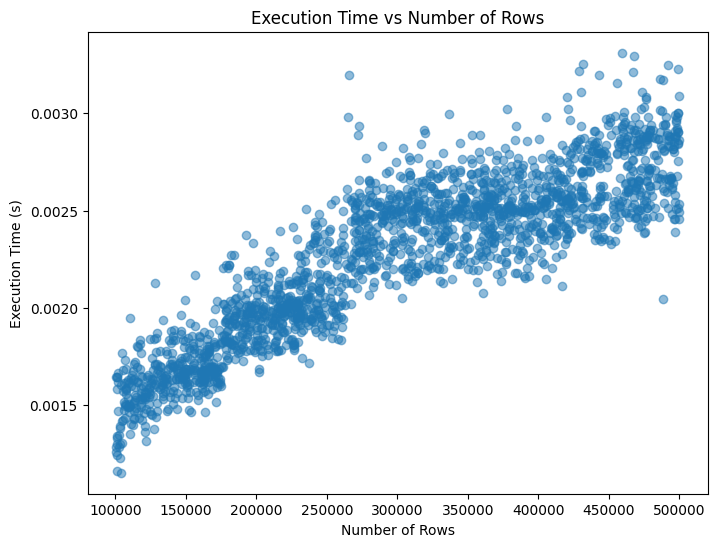

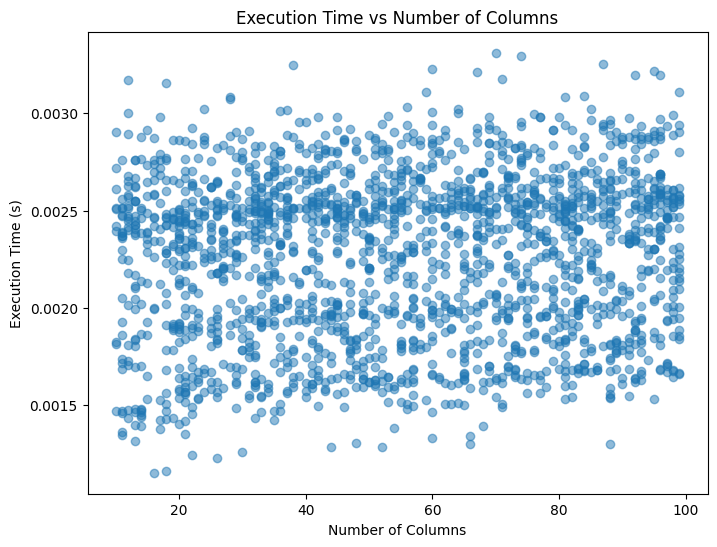

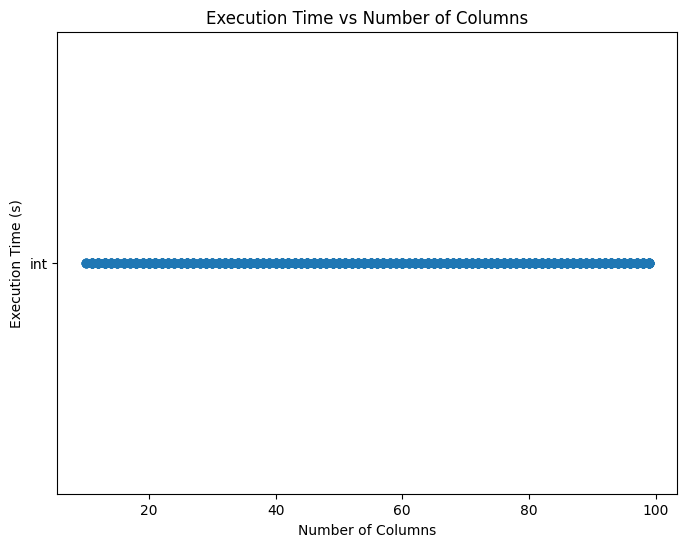

In [3]:
### plotting

# Plot Execution Time vs Number of Rows
plt.figure(figsize=(8, 6))
plt.scatter(df_results["n_rows"], df_results["time"], alpha=0.5)
plt.xlabel("Number of Rows")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Number of Rows")
plt.show()

# Plot Execution Time vs Number of Columns
plt.figure(figsize=(8, 6))
plt.scatter(df_results["num_cols"], df_results["time"], alpha=0.5)
plt.xlabel("Number of Columns")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Number of Columns")
plt.show()

# Plot Execution Time vs Number of Columns
plt.figure(figsize=(8, 6))
plt.scatter(df_results["num_cols"], df_results["unique_dtype"], alpha=0.5)
plt.xlabel("Number of Columns")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Number of Columns")
plt.show()

In [4]:
# Prepare features and target for the regression model.
# Here we include: n_rows, num_cols, threshold, and counts of each data type.
X = df_results[["n_rows", "num_cols", "cardinality", "unique_dtype"]]
y = df_results["time"]
encoder = LabelEncoder()
# Ensure NaN ratios didn't create NaN strings before encoding

X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# --- Choose and Train your Model ---
print("\nTraining Model...")
# model = LinearRe(n_estimators=200,
#                               random_state=42,
#                               n_jobs=-1,
#                               max_depth=50,
#                               # min_samples_split=5,
#                               # min_samples_leaf=3
#                              )
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")


Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000133 seconds
R² Score: 0.8416


/var/tmp/ipykernel_29250/2949218708.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["unique_dtype"] = encoder.fit_transform(X["unique_dtype"])


In [21]:
import numpy as np
import random
import tqdm
import pandas as pd  # For final DataFrame conversion and display


# Helper function to generate a random string of fixed length.
def random_string(length=5):
    return "".join(random.choices(string.ascii_letters, k=length))


# Function to generate a cuDF DataFrame with a dedicated 'unique_col'
# whose distinct values are controlled by the 'cardinality' parameter.
# Also adds additional columns with mixed data types.
def generate_unique_df(n_rows, num_cols, cardinality, unique_dtype="int"):
    data = {}

    # Generate the 'unique_col' with controlled cardinality.
    if unique_dtype == "int":
        # For integers, generate values between 0 and (cardinality - 1)
        data["unique_col"] = np.random.randint(0, cardinality, n_rows)
    elif unique_dtype == "float":
        # For floats, generate similar integer values and cast to float.
        data["unique_col"] = np.random.randint(0, cardinality, n_rows).astype(float)
    elif unique_dtype == "string":
        # For strings, generate a fixed pool of random strings and sample from it.
        unique_values = [random_string(5) for _ in range(cardinality)]
        data["unique_col"] = np.random.choice(unique_values, n_rows)
    else:
        raise ValueError("unique_dtype must be 'int', 'float', or 'string'")

    # Add additional columns with mixed data types.
    for i in range(num_cols - 1):  # subtract one for the 'unique_col'
        col_type = random.choice(["int", "float", "string"])
        col_name = f"col_{i}"
        if col_type == "int":
            data[col_name] = np.random.randint(0, 100, n_rows)
        elif col_type == "float":
            data[col_name] = np.random.rand(n_rows)
        else:  # 'string'
            data[col_name] = [random_string(5) for _ in range(n_rows)]

    # Create a cuDF DataFrame from the generated dictionary.
    df = cudf.DataFrame(data)
    return df


# Function to count the number of columns by data type in a cuDF DataFrame.
def count_dtypes(df):
    count_int, count_float, count_str = 0, 0, 0
    for col, dtype in df.dtypes.items():
        if np.issubdtype(dtype, np.integer):
            count_int += 1
        elif np.issubdtype(dtype, np.floating):
            count_float += 1
        elif dtype == "object" or dtype.name == "object":
            count_str += 1
    return count_int, count_float, count_str


# Function to benchmark the unique operation on a given column using cuDF.
def benchmark_unique(df, col="unique_col"):
    start = time.perf_counter()
    _ = df[col].drop_duplicates()  # cuDF's equivalent of unique()
    end = time.perf_counter()
    return end - start


# Number of random samples to generate.
samples = 1000
benchmark_results = []

# List of possible data types for the unique column.
unique_dtypes = ["int", "float", "string"]

# Generate benchmark data using random values.
for _ in tqdm.tqdm(range(samples)):
    n_rows = np.random.randint(
        10000, 100000
    )  # Random number of rows between 1,000 and 10,000.
    num_cols = np.random.randint(
        10, 100
    )  # Random total number of columns between 10 and 100.
    # Set cardinality between 10 and n_rows to control the number of unique values.
    cardinality = np.random.randint(10, n_rows)
    # Randomly choose a data type for the unique column.
    unique_dtype = random.choice(unique_dtypes)

    # Generate the synthetic cuDF DataFrame.
    df = generate_unique_df(n_rows, num_cols, cardinality, unique_dtype)

    # Benchmark the unique operation on the 'unique_col'.
    elapsed_time = benchmark_unique(df, "unique_col")

    # Count the number of columns by type.
    count_int, count_float, count_str = count_dtypes(df)

    # Record the benchmark result and features.
    benchmark_results.append(
        {
            "n_rows": n_rows,
            "num_cols": num_cols,
            "cardinality": cardinality,
            "unique_dtype": unique_dtype,
            "time": elapsed_time,
            "count_int": count_int,
            "count_float": count_float,
            "count_str": count_str,
        }
    )

# Convert the results to a pandas DataFrame for easy inspection.
df_results = pd.DataFrame(benchmark_results)
print(df_results)

 13%|██████████████▉                                                                                                      | 128/1000 [03:35<24:25,  1.68s/it]


KeyboardInterrupt: 